In [11]:
import keras
from keras.layers import Conv2D, Conv2DTranspose, Dropout
from sklearn.model_selection import KFold
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Data augmentation

In [3]:
# Adds random horizontal and rotations to our CT scans and labels
# so that more data is added since we have small data.
def get_augmentation():
    return keras.Sequential([
        keras.layers.RandomFlip("horizontal_and_vertical"),
        keras.layers.RandomRotation(0.1),
    ])

# Model Creation

In [4]:
# Issue: Using a Conv3D may use up a lot of memory which could potentially
# crash the GPU.
def get_model(img_size, num_classes, depth=3):
    # X has shape: (samples, height, width, depth)
    inputs = keras.Input(shape=(*img_size, depth)) # = (512, 512, 3)

    # Add augmentation
    data_augmentation = get_augmentation()
    x = data_augmentation(inputs)



    # Use padding=same to avoid the creation of a border on feature size.
    # Max pooling is not necessary since we are using a stride of 2 which
    # already downsamples our spatial size.
    x = Conv2D(64, 3, strides=2, activation='relu', padding='same')(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    # Add dropouts to prevent overfitting
    x = Dropout(0.1)(x)

    x = Conv2D(128, 3, strides=2, activation='relu', padding='same')(x)
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    # Add dropouts to prevent overfitting
    x = Dropout(0.15)(x)

    x = Conv2D(256, 3, strides=2, activation='relu', padding='same')(x)
    x = Conv2D(256, 3, activation='relu', padding='same')(x)
    # Add dropouts to prevent overfitting
    x = Dropout(0.2)(x)

    # Transpose is uesd to retain the original spatial size and segmentations.
    x = Conv2DTranspose(256, 3, activation='relu', padding='same')(x)
    x = Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same", output_padding=1)(x)
    x = Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same", output_padding=1)(x)
    x = Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same", output_padding=1)(x)

    # Classify each output pixel with our 3 categories
    outputs = Conv2D(num_classes, 1, activation='softmax', padding='same')(x)

    return keras.Model(inputs, outputs)

# Load CT scans with our labels

In [5]:
samples = sorted(
    [d for d in os.listdir("../data/Preprocessed//CT Scans") if not d.startswith('.')]
)
print(samples)

['index', 'middle', 'pinky', 'ring']


# Load every CT scan and labels

In [6]:
def load_scan(finger):

    # Load the CT scans and labels for that specific finger (ex. index).
    image_folder = os.path.join("../data/Preprocessed/CT Scans/", finger, "S232028")
    label_folder = os.path.join("../data/Preprocessed/Labels/", finger, "S232028")

    # Ensure they are sorted in order so that the inputs match with their labels.
    image_files = sorted(f for f in os.listdir(image_folder) if f.endswith('.npy') and not f.startswith("."))
    label_files = sorted(f for f in os.listdir(label_folder) if f.endswith('.npy') and not f.startswith("."))

    images = []
    labels = []

    # Create tuples that contain the CT scans along with their labels.
    for img, lab in zip(image_files, label_files):

        # Both the image_folder and label_folder are loaded using np.load()
        # since they are .npy files, and appends them to their lists.
        images.append(
            np.load(os.path.join(image_folder, img), allow_pickle=True)
        )

        labels.append(
            np.load(os.path.join(label_folder, lab), allow_pickle=True)
        )

    # Converts the arrays from 2D to 3D
    return np.stack(images), np.stack(labels)

# Compute 3 neighboring slices to feed to our model

In [7]:
def make_multislice(volume, labels, depth=3):

    # Ensure first that the depth is odd so that the center slice is included.
    assert depth % 2 == 1
    pad = depth // 2

    # Add padding along the slice axis.
    # Adds pad slices at the beginning and end of the slice axis.
    vol = np.pad(volume, ((pad, pad), (0, 0), (0, 0)), mode='edge')
    lab = np.pad(labels, ((pad, pad), (0, 0), (0, 0)), mode='edge')

    X = []
    Y = []
    # For each slice index: X gets a stack of depth consecutive slices and Y gets the label of the center slice.
    for i in range(pad, pad + volume.shape[0]):
        X.append(vol[i - pad: i + pad + 1]) # Shape: (depth, height, width)
        Y.append(lab[i]) # Shape: (height, width)
    
    X = np.stack(X) # (samples, depth, height, width)
    Y = np.stack(Y) # (samples, height, width)
    X = np.transpose(X, (0, 2, 3, 1)) # (samples, height, width, depth)
    return X, Y

# Use Kfold cross validation for our small data

In [8]:
# Stores the accuracies and loss values for each model
res = []

# Stores the accuracies and loss values over time
history_arr = []

In [9]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.src.callbacks import callback


kf = KFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

# Size: (637, 512, 512): (slices, height, width)
img_size = (512, 512) # (height, width)

# This splits into 4 folds, each fold has k-1 CT scans that serves as training
# and one CT scan serves as our testing.
# Each CT scan will serve as our testing.
curr_model = 0
for fold, (train_i, test_i) in enumerate(kf.split(samples)):
    print("Fold:", fold)

    depth = 3 # How many slices the model will take.
    # A new model is created for each fold.
    model = get_model(img_size, 3, depth)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Stores a list of fingers: [x_index, x_middle, x_ring]
    x_train = []
    y_train = []

    # Iterate through each training data in each fold which has a total of 3 fingers.

    for finger in [samples[i] for i in train_i]:
        x, y = load_scan(finger) # returns the inputs associated with their labels.
        x, y = make_multislice(x, y, depth)
        print(x.shape, y.shape)
        x_train.append(x)
        y_train.append(y)
    
    # Concatenates into a shape of (1911, 1236, 561, 3) = (finger_samples, height, width, channels)
    # After concatenation, each slice has shape (1236, 561, 3)
    x_train = np.concatenate(x_train, axis=0)
    y_train = np.concatenate(y_train, axis=0)
    print("x_train: ", x_train.shape)
    print("y_train: ", y_train.shape)

    # Train a new model for each fold.
    # In the end, we average all the accuracies of the models.
    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=2,
        callbacks=[EarlyStopping(monitor='val_loss' , patience=3, restore_best_weights=True)],
        validation_split=0.1
    )

    history_arr.append(history)

    x_test, y_test = load_scan(samples[test_i[0]])
    x_test, y_test = make_multislice(x_test, y_test, depth)

    test_loss, test_acc = model.evaluate(x_test, y_test)

    # Appends a dictionary to the list which stores info about the current model.
    res.append({
        "fold": fold,
        "loss": test_loss,
        "accuracy": test_acc,
        "model": model,
    })

    # Save the current model for each fold
    model.save(f'../models/k-fold/model_{curr_model}.keras')

    curr_model += 1

Fold: 0


2026-03-16 21:40:19.569745: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-16 21:40:19.569771: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-16 21:40:19.569774: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1773711619.570340 2438693 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773711619.570576 2438693 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


(637, 512, 512, 3) (637, 512, 512)
(637, 512, 512, 3) (637, 512, 512)
(637, 512, 512, 3) (637, 512, 512)
x_train:  (1911, 512, 512, 3)
y_train:  (1911, 512, 512)
Epoch 1/10


2026-03-16 21:40:48.324565: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


860/860 ━━━━━━━━━━━━━━━━━━━━ 213s 242ms/step - accuracy: 0.9813 - loss: 0.1006 - val_accuracy: 0.9949 - val_loss: 0.0173
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 208s 242ms/step - accuracy: 0.9811 - loss: 0.2586 - val_accuracy: 0.9949 - val_loss: 0.0157
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 202s 235ms/step - accuracy: 0.9810 - loss: 0.2894 - val_accuracy: 0.9949 - val_loss: 0.0587
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 202s 235ms/step - accuracy: 0.9822 - loss: 0.1515 - val_accuracy: 0.9949 - val_loss: 0.0612
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 202s 235ms/step - accuracy: 0.9794 - loss: 0.6800 - val_accuracy: 0.9949 - val_loss: 0.0681
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9821 - loss: 0.0426
Fold: 1
(637, 512, 512, 3) (637, 512, 512)
(637, 512, 512, 3) (637, 512, 512)
(637, 512, 512, 3) (637, 512, 512)
x_train:  (1911, 512, 512, 3)
y_train:  (1911, 512, 512)
Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 205s 236ms/step - accuracy: 0.9800 - loss: 0.2947 - val_accuracy: 0.

In [10]:
print('History array:', history_arr)
print('Test results:', res)

History array: [<keras.src.callbacks.history.History object at 0x13bc57fb0>, <keras.src.callbacks.history.History object at 0x1408bca40>, <keras.src.callbacks.history.History object at 0x14378a3c0>, <keras.src.callbacks.history.History object at 0x1441aeb70>]
Test results: [{'fold': 0, 'loss': 0.04260512441396713, 'accuracy': 0.9821332693099976, 'model': <Functional name=functional_1, built=True>}, {'fold': 1, 'loss': 0.03578188270330429, 'accuracy': 0.9856436848640442, 'model': <Functional name=functional_3, built=True>}, {'fold': 2, 'loss': 0.07952623814344406, 'accuracy': 0.9805329442024231, 'model': <Functional name=functional_5, built=True>}, {'fold': 3, 'loss': 0.035961832851171494, 'accuracy': 0.9860543012619019, 'model': <Functional name=functional_7, built=True>}]


# Visualizations

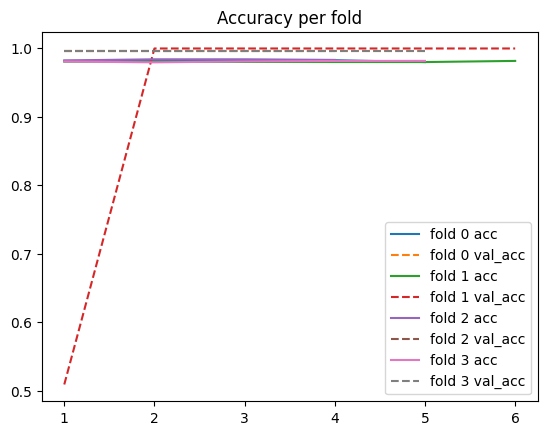

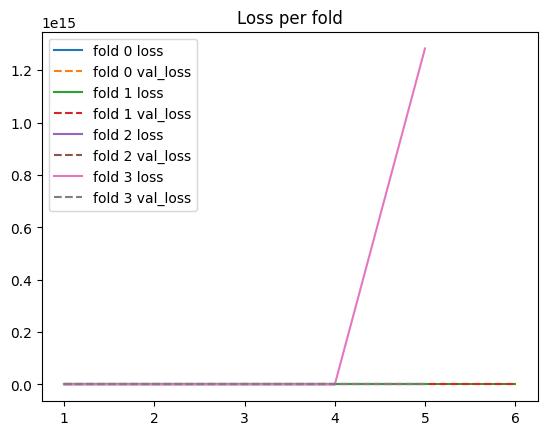

In [17]:
plt.figure()
for i, h in enumerate(history_arr):
    acc = h.history["accuracy"]
    val_acc = h.history.get("val_accuracy")
    ep = range(1, len(acc) + 1)
    plt.plot(ep, acc, label=f"fold {i} acc")
    if val_acc is not None:
        plt.plot(ep, val_acc, linestyle="--", label=f"fold {i} val_acc")
plt.title("Accuracy per fold")
plt.legend()
plt.show()

plt.figure()
for i, h in enumerate(history_arr):
    loss = h.history["loss"]
    val_loss = h.history.get("val_loss")
    ep = range(1, len(loss) + 1)
    plt.plot(ep, loss, label=f"fold {i} loss")
    if val_loss is not None:
        plt.plot(ep, val_loss, linestyle="--", label=f"fold {i} val_loss")
plt.title("Loss per fold")
plt.legend()
plt.show()

In [30]:
# Average results
avg_test_acc = sum(r['accuracy'] for r in res) / len(res)
avg_test_loss = sum(r['loss'] for r in res) / len(res)

print('Average test accuracy:', avg_test_acc)
print('Average test loss:', avg_test_loss)

Average test accuracy: 0.9835910499095917
Average test loss: 0.048468769527971745
